Прежде, чем приступать к этому ноутбуку вспомните/изучите статью про архитектуру **U-Net**.  
Вот [оригинальная статья](https://disk.yandex.ru/i/d6RZa3H2xEYSjQ), а вот [тут](https://habr.com/ru/articles/893122/) и [тут](https://habr.com/ru/companies/data_light/articles/855336/) можно почитать не только про *U-Net*, но и про другие архитектуры и сегментацию в целом.

> Напоминаю, что в этом задании **МОЖНО ИСПОЛЬЗОВАТЬ БЯМ**. Однако прошу **разбираться** в том, что вам выдают БЯМ, не верьте наслово и проверяйте!

<div class="alert alert-info">
<i>В этой домашке вам скорее всего понадобятся мощности, поэтому заранее озаботьтесь доступом к <b>Google Colab</b> и <b>временем на обучение</b>.</i>
</div>

***

Вы уже познакомились со свёрточными нейронными сетями и задачей классификации изображений. Однако классификация даёт лишь один ответ на всё изображение: *«Что изображено на этой картинке?»*. В реальных приложениях часто требуется **гораздо более детальное понимание сцены** — необходимо определить, **какие именно пиксели** принадлежат интересующему нас объекту.

Ещё одной фундаментальной задачей, решаемой с помощью свёрточных сетей, является **задача семантической сегментации**. В отличие от классификации, сегментация предсказывает метку для **каждого пикселя** изображения. Это позволяет точно локализовать объекты и понять структуру сцены на пиксельном уровне.

**От классификации к сегментации**

| Задача | Вопрос | Выход | Особенность |
|--------|--------|-------|-------------|
| **Классификация** | *«Что на изображении?»* | Один класс | Теряет пространственную информацию |
| **Сегментация** | *«Где находится объект?»* | Карта меток (H×W) | Сохраняет пиксельную точность |

Классические свёрточные сети для классификации (ResNet, VGG) используют пулинг и страйды, что приводит к **потере пространственного разрешения**. Для сегментации нужны специальные подходы:

- **Архитектура encoder-decoder** (U-Net) — сжатие признаков + восстановление разрешения  
- **Skip-connections** — передача деталей из энкодера в декодер  
- **Dilated (atrous) convolutions** — увеличение поля восприятия без потери разрешения  

*Что вы сделаете в этом задании?*

1. Реализуете классический **U-Net с нуля** — поймёте принцип работы архитектуры
2. Создадите гибридную модель на базе **предобученного ResNet34** — оцените силу transfer learning
3. Научитесь бороться с дисбалансом классов и оценивать качество через **IoU** и **Dice**

> Сегментация — это не просто карта пикселей. Это первый шаг к тому, чтобы машина *понимала* мир так же, как человек.

In [ ]:
!nvidia-smi

Thu Apr  2 15:03:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
import cv2
import numpy as np

import torchvision.transforms as transforms
from torch.utils.data import Dataset

import matplotlib.pyplot as plt
%matplotlib inline

import albumentations
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim.lr_scheduler import OneCycleLR
from tqdm.auto import tqdm

# Распаковка

Распаковщик - создал в Qwen

In [ ]:
import os
import zipfile
from pathlib import Path
from typing import Union, List, Dict, Any


class ZipExtractor:
    """
    Класс для распаковки ZIP-архивов с вложенной структурой папок.
    Оптимизирован для работы с изображениями в Google Colab.
    """

    def __init__(self, encoding: str = 'utf-8'):
        self.encoding = encoding

    def inspect(self, zip_path: Path) -> Dict[str, Any]:
        """
        Проверяет валидность ZIP и показывает его содержимое без распаковки.
        """
        result = {
            'valid': False,
            'files_count': 0,
            'folders': set(),
            'png_count': 0,
            'error': None
        }

        try:
            if not zipfile.is_zipfile(zip_path):
                result['error'] = 'Не валидный ZIP файл'
                return result

            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                result['valid'] = True
                result['files_count'] = len(zip_ref.namelist())

                for name in zip_ref.namelist():
                    # Извлекаем имена папок
                    if '/' in name:
                        folder = name.rsplit('/', 1)[0]
                        result['folders'].add(folder)
                    # Считаем PNG файлы
                    if name.lower().endswith('.png'):
                        result['png_count'] += 1

                result['folders'] = list(result['folders'])

        except Exception as e:
            result['error'] = str(e)

        return result

    def extract(self, zip_path: Union[str, Path], destination: Union[str, Path] = None) -> bool:
        """
        Распаковывает архив с сохранением структуры папок.
        """
        zip_path = Path(zip_path)

        if not zip_path.exists():
            print(f"❌ Файл не найден: {zip_path}")
            print(f"   Текущая папка: {Path('.').absolute()}")
            return False

        # Проверка валидности
        inspection = self.inspect(zip_path)
        if not inspection['valid']:
            print(f"❌ Ошибка ZIP: {inspection['error']}")
            return False

        print(f"✓ ZIP валиден")
        print(f"  Файлов в архиве: {inspection['files_count']}")
        print(f"  PNG изображений: {inspection['png_count']}")
        print(f"  Папок: {len(inspection['folders'])}")

        if destination is None:
            destination = zip_path.parent
        else:
            destination = Path(destination)
            destination.mkdir(parents=True, exist_ok=True)

        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(destination)

            # Подсчет результатов
            extracted_files = list(destination.rglob('*.png'))
            print(f"✓ Распаковано успешно")
            print(f"  PNG файлов извлечено: {len(extracted_files)}")
            print(f"  Путь: {destination.absolute()}")

            return True

        except Exception as e:
            print(f"❌ Ошибка при распаковке: {type(e).__name__} - {e}")
            return False


def unzip_archive(file_path: Union[str, Path], show_contents: bool = True) -> bool:
    """
    Основная функция для вызова пользователем.
    Распаковывает архив с изображениями в ту же папку.

    :param file_path: Путь к ZIP-архиву
    :param show_contents: Показать содержимое архива перед распаковкой
    :return: Результат операции (True/False)
    """
    extractor = ZipExtractor()
    zip_path = Path(file_path)

    print(f"\n{'='*50}")
    print(f"РАСПАКОВКА: {zip_path.name}")
    print(f"{'='*50}")

    if show_contents:
        inspection = extractor.inspect(zip_path)
        if inspection['valid']:
            print(f"\n📁 Структура архива:")
            for folder in sorted(inspection['folders'])[:10]:  # Первые 10 папок
                print(f"   {folder}/")
            if len(inspection['folders']) > 10:
                print(f"   ... и еще {len(inspection['folders']) - 10} папок")
            print()

    return extractor.extract(zip_path=zip_path)


def find_and_unzip_all(directory: Union[str, Path] = '.') -> List[Dict[str, Any]]:
    """
    Находит все ZIP в папке и распаковывает их.
    Возвращает статистику по каждому архиву.
    """
    results = []
    path = Path(directory)
    zip_files = sorted(path.glob('*.zip'))

    if not zip_files:
        print("⚠️ ZIP-архивы в текущей директории не найдены.")
        print(f"   Текущая папка: {path.absolute()}")
        return results

    print(f"📦 Найдено архивов: {len(zip_files)}\n")

    for zip_file in zip_files:
        if zip_file.name.startswith('__MACOSX') or zip_file.name.startswith('.'):
            continue

        result = {
            'file': str(zip_file),
            'success': False,
            'png_count': 0
        }

        print(f"\n{'='*50}")
        extractor = ZipExtractor()
        inspection = extractor.inspect(zip_file)

        if inspection['valid']:
            result['png_count'] = inspection['png_count']
            result['success'] = extractor.extract(zip_path=zip_file)
        else:
            print(f"❌ Пропущен: {zip_file.name} ({inspection['error']})")

        results.append(result)

    # Итоговая статистика
    print(f"\n{'='*50}")
    print(f"ИТОГО:")
    print(f"  Обработано архивов: {len(results)}")
    print(f"  Успешно: {sum(1 for r in results if r['success'])}")
    print(f"  Всего PNG: {sum(r['png_count'] for r in results)}")
    print(f"{'='*50}\n")

    return results


def list_current_files() -> None:
    """
    Вспомогательная функция: показывает файлы в текущей папке.
    Полезно для отладки в Colab.
    """
    print("\n📂 Файлы в текущей директории:")
    for item in sorted(Path('.').iterdir()):
        size = item.stat().st_size if item.is_file() else 0
        print(f"   {item.name} ({size:,} байт)")
    print()

In [ ]:
# Показываем текущие файлы для отладки
list_current_files()

# Распаковываем все ZIP в текущей папке
find_and_unzip_all('.')


📂 Файлы в текущей директории:
   .config (0 байт)
   data.zip (207,633,511 байт)
   sample_data (0 байт)

📦 Найдено архивов: 1


✓ ZIP валиден
  Файлов в архиве: 1741
  PNG изображений: 1734
  Папок: 7
✓ Распаковано успешно
  PNG файлов извлечено: 1734
  Путь: /content

ИТОГО:
  Обработано архивов: 1
  Успешно: 1
  Всего PNG: 1734



[{'file': 'data.zip', 'success': True, 'png_count': 1734}]

# Подготовка данных

Будем работать с сегментацией дорог, оригинальный датасет можно найти [по этой ссылке](https://www.cvlibs.net/datasets/kitti/eval_road.php). Их изображения имеют размер $\pm$370х1270, но для простоты мы будем использовать квадраты размером 370х370.  
Вы можете скачать датасет с диска вот [тут](https://disk.yandex.ru/d/hFh2B_tawbrqzg).  

Напишем **класс датасета** для работы с нашими данными (вы понимаете что это и как из прошлого дз).

In [ ]:
def get_paths(path):
    _, _, filenames = next(os.walk(path))

    images_paths = []
    for filename in sorted(filenames):
        images_paths.append(os.path.join(path, filename))

    return images_paths

In [ ]:
class RoadDataset(Dataset):
    # TODO: дополните класс, можете спокойно его менять так, как вам нужно
    def __init__(self, images, masks, transform, img_transform=None, aug=None,):
        self.images = sorted(images)
        self.masks = sorted(masks)
        self.transform = transform
        self.img_transform = img_transform
        self.aug = aug

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        im_name = self.images[idx]
        mask_name = self.masks[idx]

        image = cv2.imread(im_name)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_name, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)

        if self.aug:
            sample = self.aug(
                image=image,
                mask=mask,
            )
        else:
            sample = {
                'image': image,
                'mask': mask,
            }

        sample['image'] = self.transform(sample['image']).float()
        sample['mask'] = self.transform(sample['mask']).float()

        if self.img_transform:
            sample['image'] = self.img_transform(sample['image']).float()

        return sample

Вспомним то, что делали в и прошлой домашке: нужно добавить **аугментации** для обработки изображений. Выбирайте те, которые хотите! Можете поставить самые базовые, а если будет плохо учиться, то потом измените.  
Как всегда делаем жесткие аугментации только для обучения, для теста и/или валидации оставляем такие, которые сильно не меняют изображение.

Набор данных невелик, поэтому активно используйте расширение данных: повороты, перевороты, изменение цвета и т.д., чтобы предотвратить переобучение.

Скорее всего, вам придется увеличить размер ваших изображений до 512x512 (это делится на 2^5 = 32, как того хочет U-Net). Используйте `PadIfNeeded`.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])
# TODO: дополните аугментации, обязательно оставьте паддинг до квадрата
train_aug = albumentations.Compose([
    albumentations.HorizontalFlip(p=0.5),
    #albumentations.VerticalFlip(p=0.5),
    #albumentations.RandomRotate90(p=0.5),
    albumentations.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    albumentations.GaussianBlur(blur_limit=(3, 7), p=0.5),
    albumentations.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
    albumentations.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT,),
])

test_aug = albumentations.Compose([
    albumentations.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT),
])

/tmp/ipykernel_3018/3226977830.py:11: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  albumentations.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),


Теперь загрузим данные и посмотрим на них

In [ ]:
DATA_PATH = "data" # измените, если у вас не так
X_train_all = get_paths(os.path.join(DATA_PATH, "train", "images"))
y_train_all = get_paths(os.path.join(DATA_PATH, "train", "gt"))

X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all,
    test_size=0.2, # можно менять
    random_state=666, # можно менять
    shuffle=True
)

X_test  = get_paths(os.path.join(DATA_PATH, "test", "images"))
y_test  = get_paths(os.path.join(DATA_PATH, "test", "gt"))

In [ ]:
# TODO: загрузите и обработайте датасеты для обучения, валидации и теста
train_dataset = RoadDataset(X_train, y_train, transform=transform, aug=train_aug)
val_dataset   = RoadDataset(X_val, y_val,   transform=transform, aug=train_aug)
test_dataset  = RoadDataset(X_test,  y_test,  transform=transform, aug=test_aug)

In [ ]:
print(f"Dataset length {len(train_dataset)}")

Dataset length 518


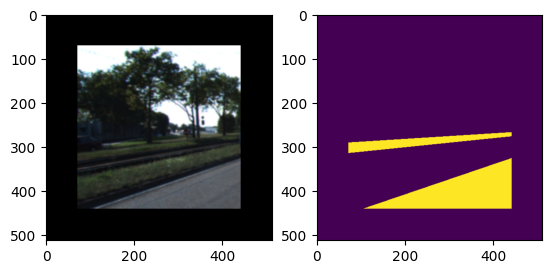

In [ ]:
sample = train_dataset[110]
image = sample['image']
mask = sample['mask']

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(mask.permute(1, 2, 0))

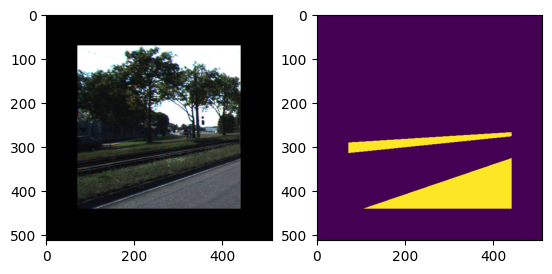

In [ ]:
sample = train_dataset[110]
image = sample['image']
mask = sample['mask']

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(mask.permute(1, 2, 0))

> Как работает паддинг?
> Если вы использовали БЯМ, то напишите, что получилось сразу, что нет, что он вам посоветовал, а что (и почему) вы изменили сами.

**ТУТ ДОЛЖНЫ БЫТЬ ВАШИ СЛОВА**

Паддинг дополняет границы картинки нулями (черными пикселями) так, чтобы привести ее к нужному размеру.

Как использовал БЯМ:
- Для написания кода для парсинга zip-файла (пришлось помучиться с "system" промптом, чтобы модель выдавала код с минимумом лишних архитектурных заморочек, при этом легко редактируемый и понимаемый). Вроде получилось. Также модель делала сначала для распаковки текстовых файлов. Пришлось уточнять, что у меня .png
- Для выдачи теории о том, какие есть функции аугментации (т.к. я забыл), чтобы сэкономить время на гуглении.
- Для рекомендаций, какие в данной задаче лучше использовать аугментации и с какими параметрами.

Из рекомендованных аугментаций я решил взять только две - это ShiftScaleRotate (для обрезки, масштабирования и поворота) и GaussNoise (для имитации шума камеры)
Почему: мне кажется, что этих аугментаций достаточно. И так много вариантов получается, не хочется делать датасет слишком большим, чтобы обучение не затянулось.




# Задание и вспомогательные штуки

Ваша цель в этом задании — использовать нужные архитектуры и обучить модели так, чтобы получить метрику **IoU** не ниже порога.

> В первой части вам нужно написать архитектуру **U-Net** с нуля и добиться метрики $\geqslant$ 0.75;  
> во второй части вам нужно использовать предобученную модель и получить IoU $\geqslant$ 0.85.

Для простоты для вас уже написаны шаблоны, но в целом вы можете делать что угодно, придерживаясь двух строк выше. Вам запрещено делать только одно: обучаться на тестовом датасете.

**Оформите ноутбук так, чтобы он легко читался и все ваши мысли были оформлены текстом**

***

В наборе данных существует явный дисбаланс классов данных, поэтому выходные данные сети будут смещены в сторону "нулевого" класса. Поэтому нужно придумать, как с этим работать.

* Вы можете либо настроить минимальный порог вероятности для класса "дорога", либо добавить веса классов для оптимизации потерь.
* Вы также можете попробовать использовать `softIoU` или `DICE loss`.

В любом случае важно разобраться с **метриками**, которые можно использовать в такой задаче.

Для оценки итогового качества мы будем использовать метрику **IoU (Intersection over Union)**. Как она считается можно почитать в интернетах или посмотреть на эту картинку  

Тут же вы можете посмотреть, как работает `Dice`)

Напишем функции, которые вам помогут посчитать эти метрики. Так как вы будете работать с тензорами в торче, то надо использовать его. Однако где-то (при итоговом подсчете мб) вам может понадобиться и реализация на numpy.

In [ ]:
def calc_iou_np(prediction, ground_truth):
    n_images = len(prediction)
    intersection, union = 0, 0
    for i in range(n_images):
        intersection += np.logical_and(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum()
        union += np.logical_or(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum()
    return float(intersection) / union

def calc_iou_torch(prediction, ground_truth):
    intersection = (prediction * ground_truth).sum()
    union = (prediction + ground_truth - prediction * ground_truth).sum()
    return (intersection / (union + 1e-6)).item()

Также сделаем еще одну вспомогательную функцию, которая поможет брать исходное изображение

In [ ]:
def central_crop(images, size):
    current_size = images.size(2)
    border_len = (current_size - size) // 2
    images = images[:, :, border_len:current_size-border_len, border_len:current_size-border_len]
    return images

In [ ]:
# Без GPU можно, но будет долго
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    device = torch.device('cpu')
print(device)

cuda:0


# U-net

## Architecture

Будем самостоятельно строить архитектуру вида *U-Net*.   
В качестве основы (сверточного блока) возьмем тот блок, который **реализовывали в прошлом задании** (можете просто скопировать).

In [ ]:
# TODO: дополните класс
class ConvBNRelu(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()

        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn(self.conv(x)))
        return x

Дальше реализуем класс `MyUnet`, в котором реализуем практически оригинальную структуру (у нас будет не 4 блока, а 5).  
> Архитектура представляет собой симметричную encoder-decoder сеть с несколькими уровнями пулинга в энкодере (3→64→128→256→512→1024 каналов), несколькими уровнями транспонированных свёрток в декодере и skip-connections, соединяющими соответствующие уровни энкодера и декодера для сохранения пространственных деталей.  

Для простоты вам предоставлен шаблон, заполните его. Обратите особое внимание на размеры тензоров, входящих в слой и выходящих из него. Изучите, как работает `nn.ConvTranspose2d`.

In [ ]:
# TODO: дополните архитектуру, вы свободны изменять параметры
class MyUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.enc1 = nn.Sequential(ConvBNRelu(in_channels, 64), ConvBNRelu(64, 64))
        self.enc2 = nn.Sequential(ConvBNRelu(64, 128), ConvBNRelu(128, 128))
        self.enc3 = nn.Sequential(ConvBNRelu(128, 256), ConvBNRelu(256, 256))
        self.enc4 = nn.Sequential(ConvBNRelu(256, 512), ConvBNRelu(512, 512))
        self.enc5 = nn.Sequential(ConvBNRelu(512, 1024), ConvBNRelu(1024, 1024))
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(ConvBNRelu(1024, 512), ConvBNRelu(512, 512))
        self.upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(ConvBNRelu(512, 256), ConvBNRelu(256, 256))
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(ConvBNRelu(256, 128), ConvBNRelu(128, 128))
        self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec4 = nn.Sequential(ConvBNRelu(128, 64), ConvBNRelu(64, 64))
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        enc_output_1 = self.enc1(x)
        enc_output_2 = self.enc2(self.pool(enc_output_1))
        enc_output_3 = self.enc3(self.pool(enc_output_2))
        enc_output_4 = self.enc4(self.pool(enc_output_3))
        enc_output = self.enc5(self.pool(enc_output_4))

        dec_output_1 = self.upconv1(enc_output)
        dec_output_1 = torch.cat([dec_output_1, enc_output_4], dim=1)
        dec_output_1 = self.dec1(dec_output_1)

        dec_output_2 = self.upconv2(dec_output_1)
        dec_output_2 = torch.cat([dec_output_2, enc_output_3], dim=1)
        dec_output_2 = self.dec2(dec_output_2)

        dec_output_3 = self.upconv3(dec_output_2)
        dec_output_3 = torch.cat([dec_output_3, enc_output_2], dim=1)
        dec_output_3 = self.dec3(dec_output_3)

        dec_output_4 = self.upconv4(dec_output_3)
        dec_output_4 = torch.cat([dec_output_4, enc_output_1], dim=1)
        dec_output_4 = self.dec4(dec_output_4)

        dec_output = self.final(dec_output_4)
        return dec_output

In [ ]:
# TODO: посмотрите на архитектуру модели, вспомните, как это сделать
...

## Preparation and training

Теперь вы должны быть готовы перейти к подготовке к обучению и обучению непосредственно.  
Для обучения нам (помимо всего остального) важно задать **функцию потерь**. Мы будем использовать стандартную кросс энтропию и тот самый **Dice-loss**. Если первое уже реализовано в `nn.BCEWithLogitsLoss` (можно почитать [тут](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)), то второе надо реализовать самостоятельно.

In [ ]:
# TODO: реализуйте класс функции потерь
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        #targets = ...

        intersection = (probs*targets).sum()
        dice = (2*intersection + self.smooth)/(targets.sum() + targets.sum() + self.smooth)
        return 1 - dice

Помните мы говорили про дисбалланс классов? Предлагаю в качестве бэйзлайна решать эту проблему имеющимися: параметр **pos_weight** (почитайте про него).

Решил найти параметр pos_weight по-умному.
Т.е. буквально посчитать, какое в среднем соотношение между количеством пикселей дороги и фона. И взять это за параметр pos_weight.

Сначала, идея была такая:

In [ ]:
def get_pos_weight_param_PLOHO_weight_is_middle_weights(dataset, flag = False):
    pws = []
    img_total_dim = torch.prod(torch.tensor(dataset[0]['mask'].shape)).item()
    for i in range(4):
        sample = dataset[i]
        sample_result = sample['mask'].sum()/img_total_dim
        pws.append(1/sample_result)

    result = sum(pws) / len(pws)
    return result

def get_pos_weight_param_PLOHO_weight_is_reverse_of_middle_of_proportion(dataset, flag = False):
    pws = []
    img_total_dim = torch.prod(torch.tensor(dataset[0]['mask'].shape)).item()
    for i in range(4):
        sample = dataset[i]
        sample_result = sample['mask'].sum()/img_total_dim
        pws.append(sample_result)

    result = sum(pws) / len(pws)
    return 1/result

Первый способ не устойчивый: если дороги нет на фото, то в ``1/sample_result`` будет очень большое число, из-за чего в целом все значение параметра будет очень большим. (Не устойчивость к выбросам)


Второй способ более устойчив, но все-же, посоветовашись с БЯМ я понял, что в нем мы не учитываем реальную долю фона, а считаем, что доля фона = 100%.
Можно было исправить это, сделав ''(1 - result)/result'', но я решил переписать по красивше.

In [ ]:
def get_pos_weight_param(dataset, epsilon = 1e-6):
    total_positive = 0
    numel = dataset[0]['mask'].numel()

    for sample in dataset:
        total_positive += sample['mask'].sum()

    pos_prop = total_positive / (numel*len(dataset))
    neg_prop = 1 - pos_prop

    return neg_prop / (pos_prop + epsilon)

In [ ]:
pos_weight_calculated = get_pos_weight_param(train_dataset)
print(pos_weight_calculated)

tensor(8.1425)


In [ ]:
# TODO: добавьте значение
pos_weight = torch.tensor([pos_weight_calculated]).to(device)
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
dice_loss = DiceLoss()

Теперь напишем **функции для обучения и оценки** модели, а также сам **цикл обучения**. Вы уже должны это уметь с прошлой домашки.

In [ ]:
# TODO: дополните функции
def train_model(model, optimizer, data_loader, device, crop_size=370):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for sample in data_loader:
        images = sample['image'].to(device)
        masks = sample['mask'].to(device)

        optimizer.zero_grad()
        logits = model(images)

        logits_crop = central_crop(logits, crop_size)
        masks_crop = central_crop(masks, crop_size)

        loss = bce_loss.forward(logits_crop, masks_crop) + dice_loss.forward(logits_crop, masks_crop) # сумма bce и dice
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches


def eval_model(model, data_loader, device, crop_size=370, threshold=0.5):
    model.eval()
    total_iou = 0.0
    num_batches = 0

    with torch.no_grad(): # не обучаем, только проверяем
        for sample in data_loader:
            images = sample['image'].to(device)
            masks = sample['mask'].to(device)

            logits = model(images)

            logits_crop = central_crop(logits, crop_size)
            pred_masks = (torch.sigmoid(logits_crop) > threshold).float()
            masks_crop = central_crop(masks, crop_size)

            iou = calc_iou_torch(pred_masks, masks_crop)
            total_iou += iou
            num_batches += 1

    return total_iou / num_batches

In [ ]:
from IPython.display import clear_output
# TODO: напишите цикл обучения
def train_loop(model, optimizer, scheduler, train_loader, val_loader,
               device, num_epochs, crop_size=370, threshold=0.5, plot_every=5):
    train_losses = []
    val_ious = []

    for epoch in range(num_epochs):
        middle_epoch_train_loss = train_model(model, optimizer, train_loader, device, crop_size)
        middle_val_loss_iou = eval_model(model, val_loader, device, crop_size, threshold)
        scheduler.step(middle_val_loss_iou)
        train_losses.append(middle_epoch_train_loss)
        val_ious.append(middle_val_loss_iou)

        if (epoch + 1) % plot_every == 0 or epoch == 0:
            clear_output()

            plt.figure(figsize=(12, 4))

            plt.subplot(1, 2, 1)
            plt.plot(train_losses)
            plt.title('Training Loss')
            plt.grid(True)

            plt.subplot(1, 2, 2)
            plt.plot(val_ious)
            plt.title('Validation IoU')
            plt.ylim(0, 1)
            plt.grid(True)

            plt.tight_layout()
            plt.show()
    return train_losses, val_ious

***
**Переходим к обучению!**  
Воспользуемся стандартным даталоадером, Адамом в качестве оптимизатора.

In [ ]:
import os
import multiprocessing

print(f"Доступно CPU ядер: {os.cpu_count()}")
print(f"Рекомендуемое NUM_WORKERS: {os.cpu_count()}")

Доступно CPU ядер: 2
Рекомендуемое NUM_WORKERS: 2


In [ ]:
BATCH_SIZE = 4
NUM_WORKERS = 4 # TODO

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
model = MyUNet(in_channels = 3, out_channels = 1).to(device) # TODO

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
) # TODO

NUM_EPOCHS = 85 # TODO: 100 должно хватить, но зависит от вашего железа и наличия времени

In [ ]:
scheduler = OneCycleLR(
    optimizer = optimizer,
    max_lr = 1e-3,
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(train_loader)
)

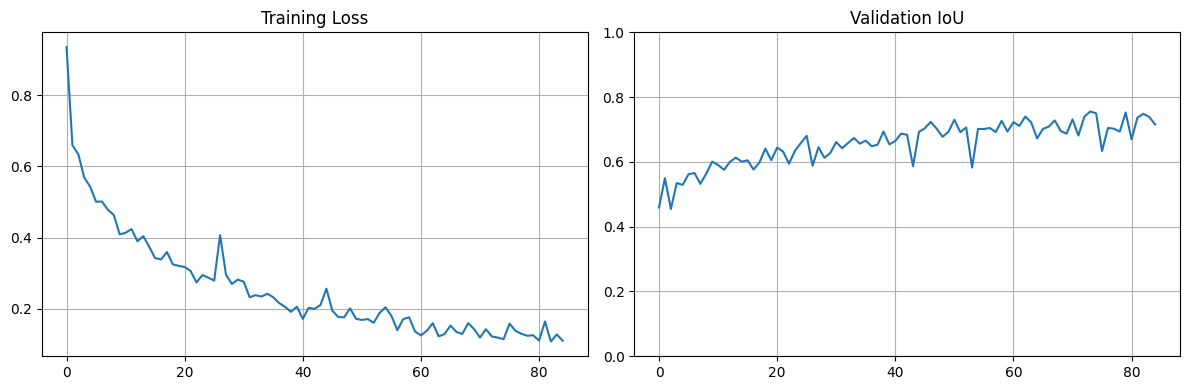

In [ ]:
# TODO: обучите модель
losses, ious = train_loop(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
    crop_size=370,
    threshold=0.5,
    plot_every=1
)

In [ ]:
print(min(losses[-10:]))
print(max(ious[-10:]))

print(losses[-5:])
print(ious[-5:])

0.1072790219520147
0.752495520494201
[0.11001440487228907, 0.16364446445726433, 0.1072790219520147, 0.12745591866282316, 0.10947735745173234]
[0.6698818414500265, 0.7368707981976595, 0.7484808898333347, 0.7386590590079626, 0.7152532167506941]


In [ ]:
torch.save(model, 'saved_model.pth')

In [ ]:
torch.save(model.state_dict(), 'saved_model_state.pth')

## Metrics and validation

После того, как вы обучили модель нужно ее оценить и посмотреть на метрики, это и сделаем

In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# TODO: дополните функцию оценка
def evaluate_on_test(model, test_loader, device=device, crop_size=370, threshold=0.5):
    model.eval()
    all_preds = []
    all_masks = []
    all_img = []

    with torch.no_grad():
        for sample in test_loader:
            images = sample['image'].to(device)
            masks = sample['mask'].to(device)

            logits = model(images)
            logits_crop = central_crop(logits, crop_size)
            pred_masks = (torch.sigmoid(logits_crop) > threshold).float()
            masks_crop = central_crop(masks, crop_size)
            images_crop = central_crop(images, crop_size)

            pred_np = pred_masks.cpu().numpy()[:, 0]
            mask_np = masks_crop.cpu().numpy()[:, 0]
            images_np = images_crop.cpu().numpy()

            all_preds.append(pred_np)
            all_masks.append(mask_np)
            all_img.append(images_np)

    all_preds = np.concatenate(all_preds, axis=0)
    all_masks = np.concatenate(all_masks, axis=0)
    all_img = np.concatenate(all_img, axis=0)

    return all_preds, all_masks, all_img

In [ ]:
predictions, ground_truth, imgs = evaluate_on_test(model, test_loader)

In [ ]:
test_iou = calc_iou_np(predictions, ground_truth)
print(f"Test IoU: {test_iou}")

assert test_iou >= 0.75

Test IoU: 0.7987947463989258


Ура-ура, нужная точность есть 🥳

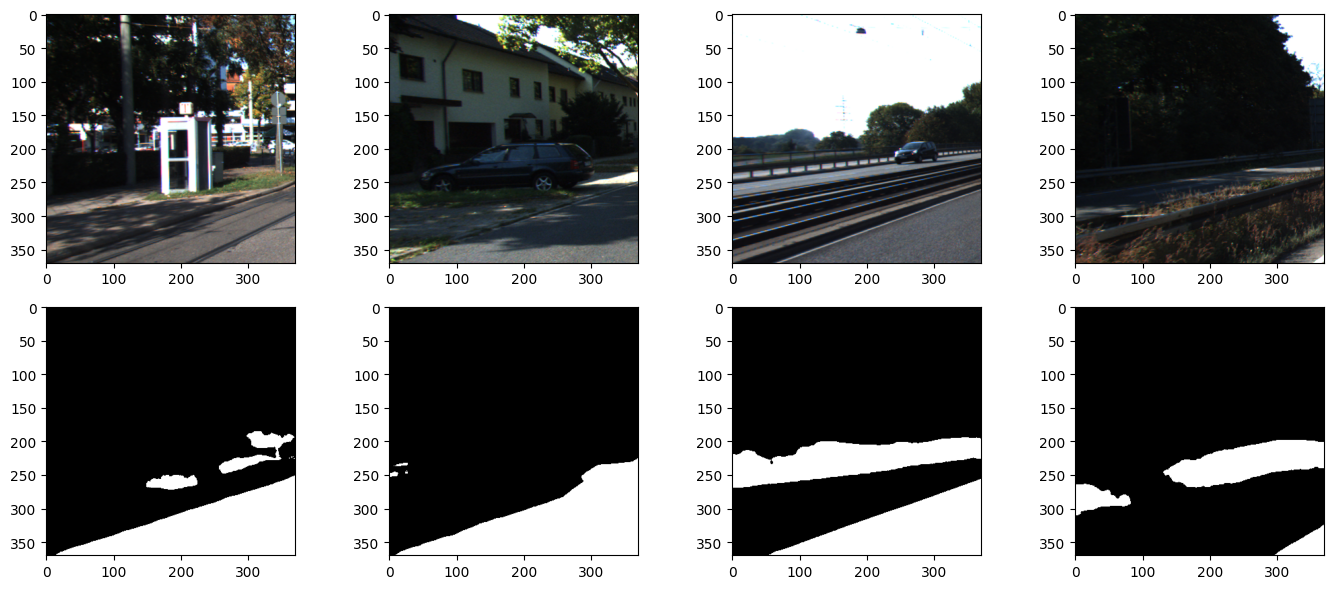

In [ ]:
indices = [1, 3, 10, 42]

plt.figure(figsize=(14, 6))
for i, idx in enumerate(indices):
    image = imgs[idx].transpose(1, 2, 0)
    mask = predictions[idx]

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)

    plt.subplot(2, 4, i + 5)
    plt.imshow(mask, cmap="gray")

plt.tight_layout()
plt.show()

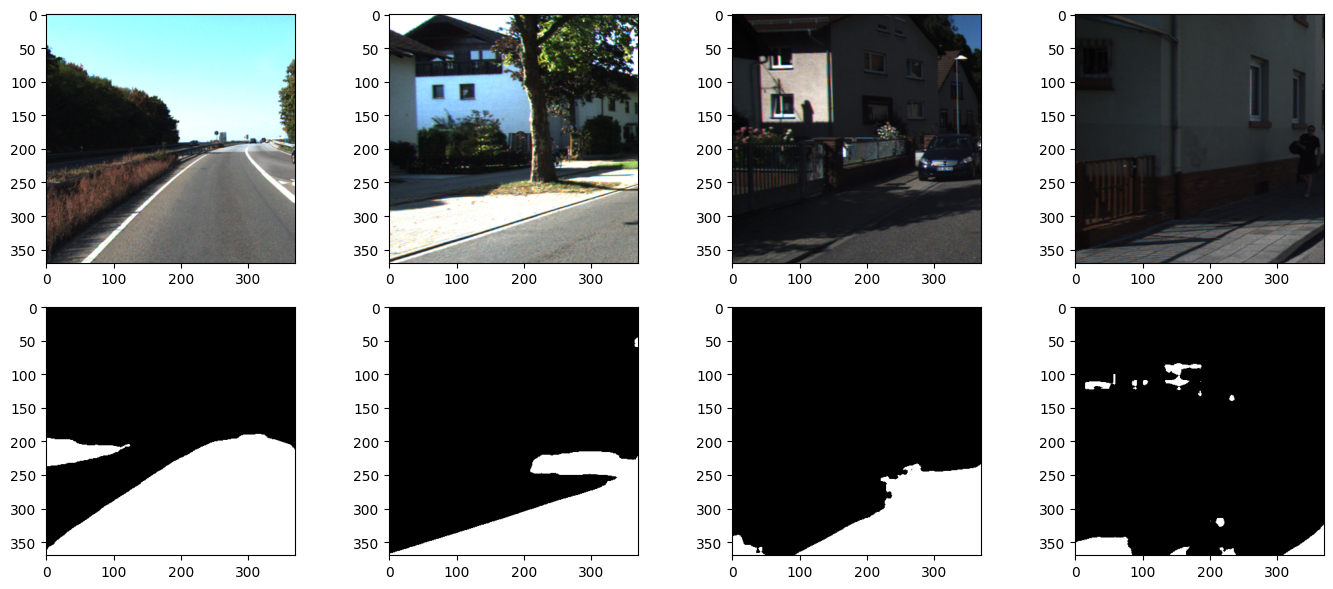

In [ ]:
indices = [120, 2, 16, 49]

plt.figure(figsize=(14, 6))
for i, idx in enumerate(indices):
    image = imgs[idx].transpose(1, 2, 0)
    mask = predictions[idx]

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)

    plt.subplot(2, 4, i + 5)
    plt.imshow(mask, cmap="gray")

plt.tight_layout()
plt.show()

**ТУТ ДОЛЖНЫ БЫТЬ ВАШИ ВИВОДЫ ПО ПОВОДУ ОБУЧЕНИЯ И МЕТРИК**

Для этой моделм я очень долго подбирал гиперпараметры...

Подробно, почему и какие параметры для аугментаций и модели я взял - описал в файле. Там я описал весь ход своих экспериментов, на основании которых подбирал гиперпараметры и аугментации.
Ссылка: https://docs.google.com/document/d/1S58Vlg7GYbcYrkh19faH5uDPgmGGB65eF9nQqXXVNtQ/edit?usp=sharing

Теперь выводы:
Если посмотреть на метрики на тесте - модель получилась довольно точной. Однако, если посмотреть на сами маски, которые выдает модель - в них довольно много артефактов (шума, который отмечен как дорога, но принадлежит фону)

Возможно, стоило взять параметр pos_weight побольше, чтобы модель сильнее штрафовалась за ложные пиксели в фоне. Надо было брать чуть больше среднего, получается.

Обучал 85 эпох. Посмотрев файл, вы могли догадаться, что я обучал модель несколько раз. Так вот, за это время я понял, что 85 эпох хватает. 100 эпох обучать не стал, так как боялся переобучить модельку.

Возможно, есть шансы обучить модельку до точности 0.8 на валидации. Но моделька начала уже выходить на плато, так что не уверен, что к 100-той эпохе точность бы достигла такого значения.

И все-таки у меня получилось выпрыгнуть из локального минимума, ураа!!!
Возможно, если бы я использовал оба подхода к динамическому изменению lr во время обучения: Сначала OneCycle, чтобы выпрыгнуть из локального минимума, а затем ReduceLROnPlateau для динамической подгонки lr в зависимости от скорости сходимости - результаты бы получились чуть лучше. Но есть ощущение, что они бы тоже не сильно были выше.

# Pretrained model

## Новые функции для обучения

Понял, что использовал scheduler (OneCycle) не так, как следовало бы. Я обновлял его раз в эпоху, а надо было раз в батч. Но да ладно, метрик же хорошие в U-Net получились. Значит не баг, а фича)

Сейчас поменял на "правильное" обновление OneCycle, так как метрики у ResNetUNet с таким подходом получились не очень. Возможно дело в целом в том, что я использую OneCycle. В общем, сейчас и поймем.

In [ ]:
def train_model_with_scheduler(model, optimizer, scheduler, data_loader, device, crop_size=370):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for sample in data_loader:
        images = sample['image'].to(device)
        masks = sample['mask'].to(device)

        optimizer.zero_grad()
        logits = model(images)

        logits_crop = central_crop(logits, crop_size)
        masks_crop = central_crop(masks, crop_size)

        loss = bce_loss.forward(logits_crop, masks_crop) + dice_loss.forward(logits_crop, masks_crop)
        loss.backward()
        optimizer.step()

        scheduler.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

def train_loop_with_scheduler_in_train(model, optimizer, scheduler, train_loader, val_loader,
               device, num_epochs, crop_size=370, threshold=0.5, plot_every=5):
    train_losses = []
    val_ious = []

    for epoch in range(num_epochs):
        middle_epoch_train_loss = train_model_with_scheduler(model, optimizer, scheduler, train_loader, device, crop_size)
        middle_val_iou = eval_model(model, val_loader, device, crop_size, threshold)

        train_losses.append(middle_epoch_train_loss)
        val_ious.append(middle_val_iou)

        if (epoch + 1) % plot_every == 0 or epoch == 0:
            clear_output()

            plt.figure(figsize=(12, 4))

            plt.subplot(1, 2, 1)
            plt.plot(train_losses)
            plt.title('Training Loss')
            plt.grid(True)

            plt.subplot(1, 2, 2)
            plt.plot(val_ious)
            plt.title('Validation IoU')
            plt.ylim(0, 1)
            plt.grid(True)

            plt.tight_layout()
            plt.show()

    return train_losses, val_ious

В целом вы уже поняли и архитектуру, и процесс обучения.  
Теперь давайте в качестве энкодера попробуем использовать уже обученную модель! Возьмем для этого предобученный **ResNet**, а также добавим нормализацию в аугментации (потому что так обучался резнет).

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

img_transform = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = RoadDataset(X_train, y_train, transform=transform, img_transform=img_transform, aug=train_aug)
val_dataset   = RoadDataset(X_val,   y_val,   transform=transform, img_transform=img_transform, aug=test_aug)
test_dataset  = RoadDataset(X_test,  y_test,  transform=transform, img_transform=img_transform, aug=test_aug)

## Architecture

Что мы хотим сделать:
* оставить логику архитектуры такой же;
* в качестве слоев энкодера поставить уже предобученные(!) слои;
* обучить модель на наших данных.

Немного поменяем количество слоев, в шаблоне все есть

In [ ]:
import torchvision.models as models
# TODO: дополнить архитектуру
#       для удобства работы с предобученным шаблон чуть изменен, но логика та же
class MyResNet34UNet(nn.Module):
    def __init__(self, out_channels=1, pretrained=True):
        super().__init__()

        resnet = models.resnet34(weights=pretrained)

        self.enc0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.pool = resnet.maxpool
        self.enc1 = resnet.layer1
        self.enc2 = resnet.layer2
        self.enc3 = resnet.layer3
        self.enc4 = resnet.layer4

        self.upconv4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec4 = nn.Sequential(ConvBNRelu(512, 256), ConvBNRelu(256, 256))
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(ConvBNRelu(256, 128), ConvBNRelu(128, 128))
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(ConvBNRelu(128, 64), ConvBNRelu(64, 64))
        self.upconv1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(ConvBNRelu(128, 64), ConvBNRelu(64, 64))
        self.upconv0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec0 = nn.Sequential(ConvBNRelu(32, 32), ConvBNRelu(32, 32))

        self.final = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        enc_output_0 = self.enc0(x)
        enc_output_1 = self.enc1(self.pool(enc_output_0))
        enc_output_2 = self.enc2(enc_output_1)
        enc_output_3 = self.enc3(enc_output_2)
        enc_output = self.enc4(enc_output_3)

        dec_output_0 = self.upconv4(enc_output)
        dec_output_0 = torch.cat([dec_output_0, enc_output_3], dim=1)
        dec_output_0 = self.dec4(dec_output_0)

        dec_output_1 = self.upconv3(dec_output_0)
        dec_output_1 = torch.cat([dec_output_1, enc_output_2], dim=1)
        dec_output_1 = self.dec3(dec_output_1)

        dec_output_2 = self.upconv2(dec_output_1)
        dec_output_2 = torch.cat([dec_output_2, enc_output_1], dim=1)
        dec_output_2 = self.dec2(dec_output_2)

        dec_output_3 = self.upconv1(dec_output_2)
        dec_output_3 = torch.cat([dec_output_3, enc_output_0], dim=1)
        dec_output_3 = self.dec1(dec_output_3)

        dec_output = self.upconv0(dec_output_3)
        dec_output = self.dec0(dec_output)

        output = self.final(dec_output)
        return output

Думал, какое количество каналов поставить в прямой и обратной свертках последнего слоя:

Было 2 варианта:
- В обратной свертке 64x64 & В прямой свертке 64x32
- В обратной свертке 64x32 & В прямой свертке 32x32

Решил поставить второй вариант, так как в стандартной архитектуре U-Net в обратной свертке происходит уменьшение количества каналов.


Пуллинг решил использовать только после нулевого энкодера, так как остальные слои мы взяли из ResNet, а значит в них уже есть max_pool. Ну и по другому модель бы не заработала, так как размерности бы не совпадали))

## Preparation and training

In [ ]:
BATCH_SIZE = 4
NUM_WORKERS = 4 # TODO

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
model = MyResNet34UNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-6) # TODO

NUM_EPOCHS = 85 # TODO

In [ ]:
scheduler = OneCycleLR(
    optimizer = optimizer,
    max_lr = 1e-3,
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(train_loader)
)

# scheduler = ReduceLROnPlateau(
#     optimizer,
#     mode='max',
#     factor=0.5,
#     patience=5,
#     threshold=1e-4
# )

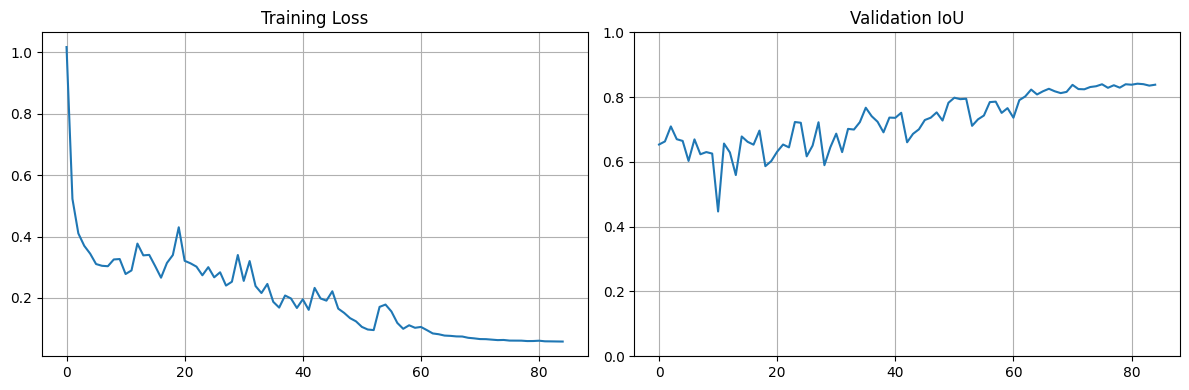

In [ ]:
# TODO: обучите модель
losses, ious = train_loop_with_scheduler_in_train(
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
    crop_size=370,
    threshold=0.5,
    scheduler=scheduler
)

In [ ]:
print(losses[-5:])
print(ious[-5:])

[0.060940875972692786, 0.059001350932969494, 0.05877969330893113, 0.05844988441811158, 0.0581876510181106]
[0.8382999996344248, 0.8414642115434011, 0.839975177338629, 0.8354904335556608, 0.8383159818071307]


In [ ]:
print(max(ious))

0.8414642115434011


Почтиии 0.85: 0.8414

## Metrics and validation

In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [ ]:
predictions, ground_truth, imgs = evaluate_on_test(model, test_loader)

test_iou = calc_iou_np(predictions, ground_truth)
print(f"Test IoU: {test_iou}")

assert test_iou >= 0.87

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Test IoU: 0.8746894001960754


Хахаха, впритык, но точность получилась))

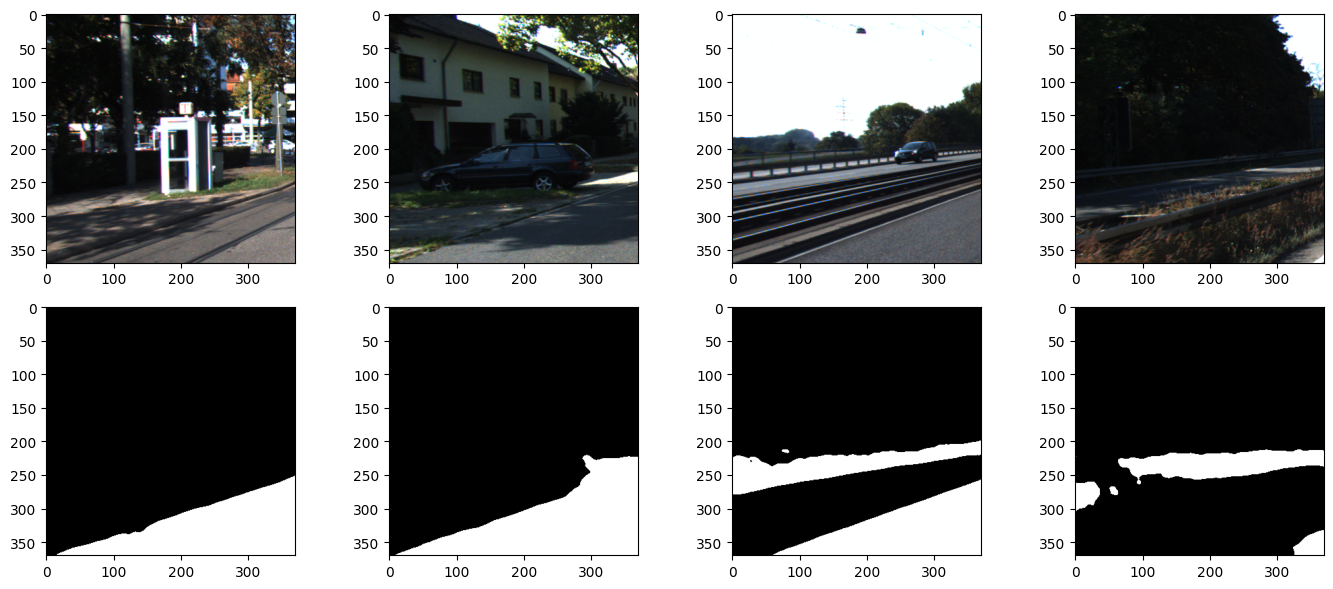

In [ ]:
indices = [1, 3, 10, 42]

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

plt.figure(figsize=(14, 6))
for i, idx in enumerate(indices):
    image = imgs[idx].transpose(1, 2, 0)
    image = image * std + mean

    mask = predictions[idx]

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)

    plt.subplot(2, 4, i + 5)
    plt.imshow(mask, cmap="gray")

plt.tight_layout()
plt.show()

**ТУТ ВАШИ ВЫВОДЫ ПРО ОБУЧЕНИЕ И РЕЗУЛЬТАТЫ**

В целом, у данной модели уже меньше артефактов. Оно и понятно, раз точность выше.

Обучение ResNet34UNet проходило гораздо быстрее, чем U-Net.
ResNet34UNet - 57 минут (85 эпох)
U-Net - чуть больше 3 часов (85 эпох)

Сначала подумал, что это может быть связано с тем, что моделька ResNet34UNet предобучена. Но поговорив с БЯМ понял, что это не так. Да, это влияет на скорость сходимости к одной и той же нужной метрике (и это очевидно), но не влияет на саму скорость обучения. А более высокая скорость обучения предобученной модельки, как я понял, связана с тем, что сама модель ResNet34UNet получилась меньше (нет слоя с 1024 параметрами, вместо него слой с 512 параметрами).

Точность получилась гораздо выше благодаря предобученным слоям.Видно, что даже при первых эпохах точность у модели уже была около 0.7. Это тоже благодаря предобученным слоям, ведь ResNet, как мне кажется, должна была видеть дороги в выборке, на которой ее обучали.

Что по поводу метода адаптации шага lr:
OneCycle per Epoch и OneCycle per Batch показали себя примерно одинаково. Жаль, что у меня при OneCycle per Epoch я не смог посмотреть результаты обучения из-за отключения от среды Google Colab. Но, если судить по графикам (которые лежат в гугл-документе), то результаты примерно одинаковые.Единственное, что, я когда смотрел на график per Epoch думал, что там модельку колбасило сильно. Но теперь, смотря на график per Batch, понимаю, что настоящий расколбас вот тут)


ReduceLROnPlateau - без резких скачков. Плавное повышение точности, плавное уменьшение ошибки. Но и результаты не высокие, около 0.75 - 0.78. Не любит чувак рисковать, предпочитает проверенную стабильность))

P.S. Ссылка на подробный отчет об обучении двух моделей:
https://docs.google.com/document/d/1S58Vlg7GYbcYrkh19faH5uDPgmGGB65eF9nQqXXVNtQ/edit?usp=sharing